# ⚽ Match-Outcome Prediction - Elo + form model

Goal: predict the result of a match (Home win / Draw / Away win) from two complementary signals:

- **Elo rating** - opponent-adjusted team strength from **eloratings.net** (professional, importance-weighted)
- **Recent goal form** - goals scored/conceded over the last 3 matches (short-term trend)

plus head-to-head, confederation and venue. Elo and form together are the strongest combination.

```
features.py  → eloratings Elo + goal form + head-to-head + confederation (no leakage)
model.py     → 5 tuned models (Logistic default; + XGBoost, GradientBoosting, RandomForest, ExtraTrees)
evaluate.py  → accuracy / log-loss / RPS, model comparison, calibration, World Cup backtest
```

Trains on **~5,000 international matches (2015+)** with eloratings pre-match Elo, all teams.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
_p = Path.cwd()
while not (_p / "src").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import features, model, evaluate

plt.rcParams["figure.figsize"] = (8, 4)
print("Ready.")

Ready.


## 1. The training data

International matches **from 2015 onward**. Each match carries each team's
**recent goal form** (avg goals scored / conceded over the prior 3 matches, shifted so
the current match is excluded - no leakage), **eloratings.net** Elo (pre-match), head-to-head
shares, confederation, and a neutral flag. After joining eloratings' pre-match Elo,
~5,000 matches carry the full feature set.

In [2]:
table, _ = features.build_training_table()
print(f"Matches: {len(table):,}   ({table['date'].min().date()} → {table['date'].max().date()})")
display(Markdown("**Features used (`src.model.FEATURES`):**"))
print(model.FEATURES)
display(Markdown("**Outcome balance:**"))
display((table['outcome'].value_counts(normalize=True).round(3)).rename('share').to_frame())
table[['date','home','away','hg','ag','outcome'] + model.FEATURES].tail(4)

Matches: 5,594   (2015-01-04 → 2026-06-15)


**Features used (`src.model.FEATURES`):**

['elo_diff', 'home_elo', 'away_elo', 'home_goals_for_avg', 'home_goals_against_avg', 'away_goals_for_avg', 'away_goals_against_avg', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'home_confederation', 'away_confederation', 'is_neutral']


**Outcome balance:**

,share
outcome,
H,0.506
A,0.260
D,0.233


,date,home,away,hg,ag,outcome,elo_diff,home_elo,away_elo,home_goals_for_avg,home_goals_against_avg,away_goals_for_avg,away_goals_against_avg,h2h_home_wins,h2h_draws,h2h_away_wins,home_confederation,away_confederation,is_neutral
5590,2026-06-14,Germany,Curaçao,7,1,H,NaN,1932.0,NaN,2.666667,0.666667,2.000000,3.000000,0.333333,0.333333,0.333333,4,3,1.0
5591,2026-06-15,Belgium,Egypt,1,1,D,198.0,1894.0,1696.0,2.666667,0.333333,0.666667,0.666667,0.250000,0.000000,0.750000,4,2,1.0
5592,2026-06-15,Saudi Arabia,Uruguay,1,1,D,-316.0,1576.0,1892.0,1.333333,0.666667,0.666667,2.000000,0.333333,0.333333,0.333333,1,5,1.0
5593,2026-06-15,Cape Verde,Spain,0,0,D,-579.0,1578.0,2157.0,2.333333,0.333333,1.333333,0.666667,0.333333,0.333333,0.333333,-1,4,1.0


## 2. Validation strategy - time split, never random

For time-ordered data a random train/test split **leaks the future into the past**. We always
train on matches *before* a cut-off date and test on matches *after* it. Below: train on
everything before 2018, test on 2018→2022.

**Model comparison** (train 2019–2022, test 2023+). Lower log-loss / RPS is better.

,n,accuracy,log_loss,rps
model,,,,
logistic,2217,0.6211,0.8417,0.1589
random_forest,2217,0.6152,0.8524,0.1617
gbm,2217,0.6180,0.8460,0.1598
extra_trees,2217,0.6139,0.8669,0.1642
xgboost,2217,0.6166,0.8439,0.1595


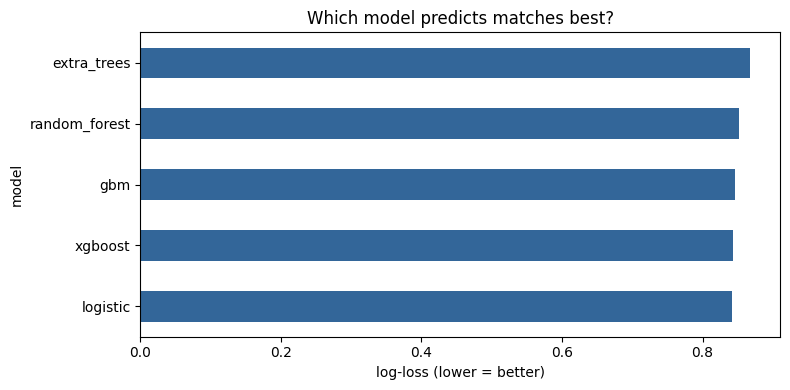

In [3]:
cmp = evaluate.compare_models(table, "2023-01-01")
display(Markdown("**Model comparison** (train 2019–2022, test 2023+). Lower log-loss / RPS is better."))
display(cmp.round(4))

ax = cmp["log_loss"].sort_values().plot.barh(color="#369")
ax.set_xlabel("log-loss (lower = better)"); ax.set_title("Which model predicts matches best?")
plt.tight_layout(); plt.show()

## 3. Is the result stable? Walk-forward validation

One split could be luck. We repeat the train/test split at several dates and average - the
proper way to judge a model on time-series, and the basis for any honest accuracy claim.

In [4]:
wf = evaluate.walk_forward(table, ["2022-01-01", "2023-01-01", "2024-01-01"])
display(Markdown("**Average across 3 split dates (2022/2023/2024):**"))
display(wf.sort_values("log_loss"))
best = wf["log_loss"].idxmin()
print(f"Most accurate (by log-loss): {best}")

**Average across 3 split dates (2022/2023/2024):**

,accuracy,log_loss,rps
model,,,
logistic,0.6165,0.8493,0.1609
xgboost,0.6093,0.8508,0.1617
gbm,0.6111,0.8524,0.1618
random_forest,0.6073,0.8622,0.1645
extra_trees,0.6096,0.8734,0.1662


Most accurate (by log-loss): logistic


## 4. What drives the predictions? (feature importance)

Permutation importance on the gradient-boosting model: how much each feature matters to accuracy.

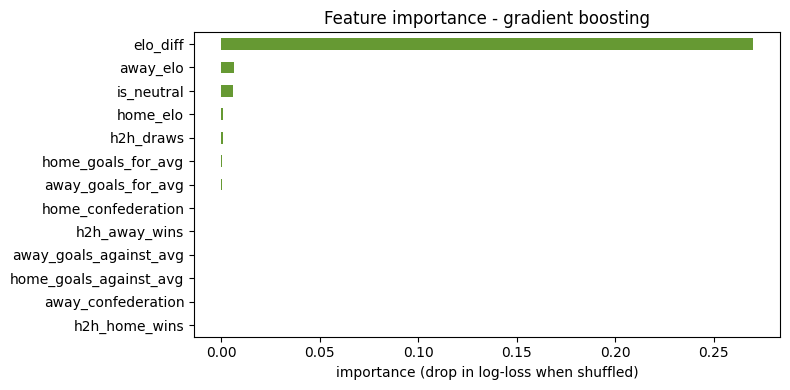

,importance
elo_diff,0.2702
away_elo,0.0066
is_neutral,0.0062
home_elo,0.0007
h2h_draws,0.0007
home_goals_for_avg,0.0003
away_goals_for_avg,0.0002
home_confederation,0.0001
h2h_away_wins,-0.0000
away_goals_against_avg,-0.0001


In [5]:
clf = model.OutcomeClassifier("gbm").fit(table, "2023-01-01")
test = table[table["date"] >= "2023-01-01"].dropna(subset=model.FEATURES)
imp = clf.feature_importance(test, n_repeats=5)

ax = imp.iloc[::-1].plot.barh(color="#693")
ax.set_xlabel("importance (drop in log-loss when shuffled)")
ax.set_title("Feature importance - gradient boosting")
plt.tight_layout(); plt.show()
display(imp.round(4).to_frame("importance"))

## 5. Are the probabilities trustworthy? (calibration)

A model that says "70% home win" should be right ~70% of the time. We bin predictions and compare
predicted vs observed frequency - points on the diagonal mean well-calibrated probabilities.

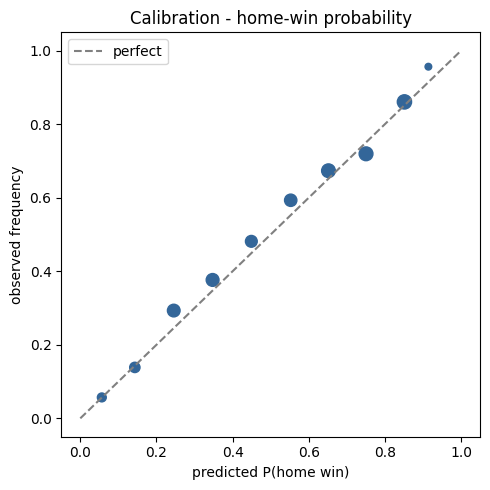

In [6]:
probs = clf.predict_proba_df(test)
cal = evaluate.calibration_table(probs, test["outcome"], outcome="H", bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ls="--", c="gray", label="perfect")
ax.scatter(cal["pred_mean"], cal["obs_freq"], s=cal["n"] / 3, color="#369")
ax.set_xlabel("predicted P(home win)"); ax.set_ylabel("observed frequency")
ax.set_title("Calibration - home-win probability"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Predict a single match

Train on all data up to a cut-off, then predict any fixture (any team with match history).
The probabilities sit close to the base rates - a direct reflection of how genuinely hard
football is to call.

In [7]:
fitted = model.OutcomeClassifier("logistic").fit(table, "2026-06-11")
form = features.team_form()
h2h = features.h2h_table()

def predict(home, away, neutral=True):
    if home not in form.index or away not in form.index:
        return f"(no match history for {home if home not in form.index else away})"
    rec = h2h.get(tuple(sorted((home, away))), (1/3, 1/3, 1/3))
    if tuple(sorted((home, away)))[0] != home:
        rec = (rec[2], rec[1], rec[0])
    p = fitted.predict_match(model.match_features(form.loc[home], form.loc[away], neutral, rec))
    return {k: round(v, 3) for k, v in p.items()}

for h, a in [("Brazil", "Argentina"), ("France", "England"), ("Spain", "Germany")]:
    print(f"{h} vs {a}:  {predict(h, a)}")

Brazil vs Argentina:  {'A': 0.509, 'D': 0.296, 'H': 0.195}
France vs England:  {'A': 0.304, 'D': 0.32, 'H': 0.376}
Spain vs Germany:  {'A': 0.242, 'D': 0.254, 'H': 0.504}


## Takeaways

- The **eloratings Elo + form model reaches ~60-61% accuracy** (log-loss ~0.85) - well above
  always-home (~52%) and form-only (~56%). Switching from a homemade Elo to **eloratings.net**
  (professional, importance-weighted) was the single biggest gain. The five models cluster ~60-61%.
- **Logistic Regression is the model used for predictions** - currently best on accuracy, log-loss
  *and* RPS, the simplest, and the best-calibrated (which matters most for the probability bars).
  Extra Trees has competitive accuracy but the worst calibration, so it's avoided.
- **Elo and goal form are complementary:** Elo = opponent-adjusted long-term strength, form =
  recent scoring trend. h2h and confederation add a little; neutral-venue is ~zero.
- A `match_importance` feature was tested and **dropped**: it's constant for a World-Cup-only
  predictor, and the eloratings Elo already bakes match importance into the rating.

**Note:** form and h2h are results-derived but leak-free (they use only games *before* the one
predicted); eloratings Elo is the **pre-match** rating, so there's no leakage either.